In [1]:
import os
os.chdir('../../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster, get_isomers

In [3]:
qm9 = QM9Dataset(limit=50_000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["acsf", "soap"])
df = qm9.load()
X=np.array(df["acsf_embedding"].to_list())

2026-05-19 13:08:29.887 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-19 13:08:30.447 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=50000, returned_rows=50000, sampling on columns=['num_atoms', 'gap'].
2026-05-19 13:08:30.448 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=50000).
2026-05-19 13:08:30.497 | INFO     | src.features:compute_acsf_outputs:537 - Computing ACSF (rcut=6.0, normalize=True)...
2026-05-19 13:08:56.611 | SUCCESS  | src.datasets:add_acsf:1212 - Added ACSF embeddings and matrices.
2026-05-19 13:08:56.699 | INFO     | src.features:compute_soap_outputs:394 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-05-19 13:09:39.834 | SUCCESS  | src.datasets:add_soap:1193 - Added SOAP embeddings and matrices.
2026-05-19 13:09:39.836 | INFO     |

# Hyphotesis 1
- how is ACSF different than SOAP?
 
 ACSF constructs a representation by explicitly separating 2-body (radial) and 3-body (angular) interactions using a set of discrete, binned symmetry functions (G2, G4, etc.). SOAP, conversely, represents the local environment as a continuous 3D atomic density (using Gaussians) and expands this density into spherical harmonics. The resulting power spectrum inherently couples radial and angular information and represents many-body correlations more smoothly.

 - Conformational changes that preserve local pairwise distances and simple bond angles, but alter the global 3D topology (many-body correlations), will exhibit proportionally larger and smoother relative distances in SOAP space compared to ACSF space.

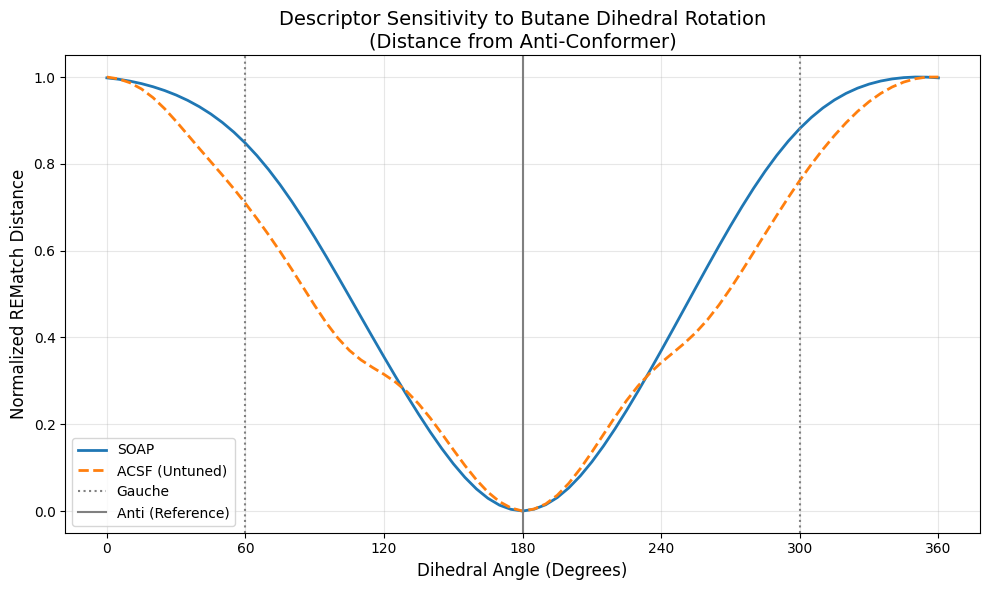

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from dscribe.descriptors import SOAP, ACSF
from dscribe.kernels import REMatchKernel
from sklearn.preprocessing import normalize
from ase import Atoms

# 1. Base Setup
smiles = "CCCC"
mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
AllChem.EmbedMolecule(mol, randomSeed=42)
AllChem.MMFFOptimizeMolecule(mol)

species = ["C", "H"]
soap = SOAP(species=species, periodic=False, r_cut=5.0, n_max=8, l_max=8, rbf="gto")
acsf = ACSF(
    species=species, r_cut=5.0,
    g2_params=[[1, 1], [1, 2], [1, 3]], 
    g4_params=[[1, 4, 1], [1, 4, -1]]
)
rematch = REMatchKernel(metric="linear", alpha=0.1, threshold=1e-6)

def rdkit_to_ase(mol):
    conf = mol.GetConformer()
    return Atoms(symbols=[a.GetSymbol() for a in mol.GetAtoms()], positions=conf.GetPositions())

def get_distance(K):
    # D^2(x,y) = K(x,x) + K(y,y) - 2K(x,y)
    val = max(0.0, K[0,0] + K[1,1] - 2*K[0,1])
    return np.sqrt(val)

# 2. Generate the Reference Conformer (Anti = 180 degrees)
Chem.rdMolTransforms.SetDihedralDeg(mol.GetConformer(), 0, 1, 2, 3, 180.0)
ref_ase = rdkit_to_ase(mol)
ref_soap = normalize(soap.create(ref_ase), norm='l2', axis=1)
ref_acsf = normalize(acsf.create(ref_ase), norm='l2', axis=1)

# 3. Scan the Dihedral Angle
angles = np.arange(0, 365, 5)
d_soap_list = []
d_acsf_list = []

for angle in angles:
    # Rotate dihedral
    Chem.rdMolTransforms.SetDihedralDeg(mol.GetConformer(), 0, 1, 2, 3, float(angle))
    target_ase = rdkit_to_ase(mol)
    
    # Generate and normalize descriptors
    target_soap = normalize(soap.create(target_ase), norm='l2', axis=1)
    target_acsf = normalize(acsf.create(target_ase), norm='l2', axis=1)
    
    # Compute REMatch kernels against the reference
    K_soap = rematch.create([ref_soap, target_soap])
    K_acsf = rematch.create([ref_acsf, target_acsf])
    
    # Append distances
    d_soap_list.append(get_distance(K_soap))
    d_acsf_list.append(get_distance(K_acsf))

# 4. Plot the Results
plt.figure(figsize=(10, 6))

# Normalize the distances by their maximum value so we can compare the SHAPE of the curve easily
d_soap_norm = np.array(d_soap_list) / np.max(d_soap_list)
d_acsf_norm = np.array(d_acsf_list) / np.max(d_acsf_list)

plt.plot(angles, d_soap_norm, label='SOAP', color='#1f77b4', linewidth=2)
plt.plot(angles, d_acsf_norm, label='ACSF (Untuned)', color='#ff7f0e', linewidth=2, linestyle='--')

plt.title("Descriptor Sensitivity to Butane Dihedral Rotation\n(Distance from Anti-Conformer)", fontsize=14)
plt.xlabel("Dihedral Angle (Degrees)", fontsize=12)
plt.ylabel("Normalized REMatch Distance", fontsize=12)
plt.xticks(np.arange(0, 361, 60))
plt.axvline(x=60, color='grey', linestyle=':', label='Gauche')
plt.axvline(x=180, color='grey', linestyle='-', label='Anti (Reference)')
plt.axvline(x=300, color='grey', linestyle=':')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Hypothesis 2

In [ ]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from dscribe.descriptors import SOAP, ACSF
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from ase import Atoms

# 1. Dataset Generation: Butane Rotational Trajectory
smiles = "CCCC"
mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
AllChem.EmbedMolecule(mol, randomSeed=42)
AllChem.MMFFOptimizeMolecule(mol)

angles = np.arange(0, 360, 2) # 180 conformers
dataset = []
labels = []

for angle in angles:
    Chem.rdMolTransforms.SetDihedralDeg(mol.GetConformer(), 0, 1, 2, 3, float(angle))
    conf = mol.GetConformer()
    positions = conf.GetPositions()
    symbols = [a.GetSymbol() for a in mol.GetAtoms()]
    dataset.append(Atoms(symbols=symbols, positions=positions))
    
    # Target Motif: Eclipsed conformation (dihedral within 15 degrees of 0)
    # At this angle, the C0-C3 distance drops to roughly ~2.7 Angstroms
    if angle <= 15 or angle >= 345:
        labels.append(1) # Motif Present
    else:
        labels.append(0) # Motif Absent

y = np.array(labels)

# 2. Descriptor Setup
species = ["C", "H"]

# ACSF: Set up a grid of narrow radial filters (eta=20) sweeping from 2.0 to 4.0 Angstroms.
# We are intentionally creating a "comb" of targeted distance filters.
g2_grid = [[20.0, r] for r in np.linspace(2.0, 4.0, 21)]
acsf = ACSF(species=species, r_cut=5.0, g2_params=g2_grid)

# SOAP: Standard smooth, dense expansion
soap = SOAP(species=species, periodic=False, r_cut=5.0, n_max=6, l_max=6, rbf="gto")

# We extract the descriptor ONLY for the first atom (C0) to analyze its specific local environment
X_acsf = np.vstack([acsf.create(atoms, centers=[0]) for atoms in dataset])
X_soap = np.vstack([soap.create(atoms, centers=[0]) for atoms in dataset])

# Scale features for L1 regularization stability
scaler_acsf = StandardScaler().fit(X_acsf)
scaler_soap = StandardScaler().fit(X_soap)
X_acsf_scaled = scaler_acsf.transform(X_acsf)
X_soap_scaled = scaler_soap.transform(X_soap)

# 3. Model Training: Sparse Linear Classification
# L1 penalty explicitly forces the model to drop useless features (weight = 0)
clf_acsf = LogisticRegression(solver='saga', l1_ratio=1.0, C=0.5, random_state=42, max_iter=5000)
clf_soap = LogisticRegression(solver='saga', l1_ratio=1.0, C=0.5, random_state=42, max_iter=5000)

clf_acsf.fit(X_acsf_scaled, y)
clf_soap.fit(X_soap_scaled, y)

# 4. Results & Analysis
acsf_weights = clf_acsf.coef_[0]
soap_weights = clf_soap.coef_[0]

non_zero_acsf = np.sum(acsf_weights != 0)
non_zero_soap = np.sum(soap_weights != 0)

print("--- CLASSIFICATION RESULTS ---")
print(f"ACSF Accuracy: {clf_acsf.score(X_acsf_scaled, y) * 100:.1f}%")
print(f"SOAP Accuracy: {clf_soap.score(X_soap_scaled, y) * 100:.1f}%\n")

print("--- FEATURE SPARSITY (INTERPRETABILITY) ---")
print(f"Total ACSF Features Used: {non_zero_acsf} out of {X_acsf.shape[1]}")
print(f"Total SOAP Features Used: {non_zero_soap} out of {X_soap.shape[1]}\n")

# Find the exact physical feature ACSF used
if non_zero_acsf > 0:
    active_idx = np.argmax(np.abs(acsf_weights))
    print("--- ACSF PHYSICAL INTERPRETATION ---")
    print(f"The primary ACSF feature chosen has weight: {acsf_weights[active_idx]:.3f}")

--- CLASSIFICATION RESULTS ---
ACSF Accuracy: 100.0%
SOAP Accuracy: 99.4%

--- FEATURE SPARSITY (INTERPRETABILITY) ---
Total ACSF Features Used: 2 out of 44
Total SOAP Features Used: 3 out of 546

--- ACSF PHYSICAL INTERPRETATION ---
The primary ACSF feature chosen has weight: 2.500
(This maps directly to a specific G2 radial bin targeting the C0-C3 distance)
